<a href="https://colab.research.google.com/github/nikhilfendre/CSL701-CS15-Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Nikhil Prasad Fendre                                                  
Roll NO : 15




### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.ensemble import BaggingClassifier

In [24]:
df = pd.read_csv("pima-indians-diabetes.csv")

df.columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

print(df.head())
print(df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            1       85             66             29        0  26.6   
1            8      183             64              0        0  23.3   
2            1       89             66             23       94  28.1   
3            0      137             40             35      168  43.1   
4            5      116             74              0        0  25.6   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.351   31        0  
1                     0.672   32        1  
2                     0.167   21        0  
3                     2.288   33        1  
4                     0.201   30        0  
(767, 9)


## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Outcome
0    500
1    267
Name: count, dtype: int64


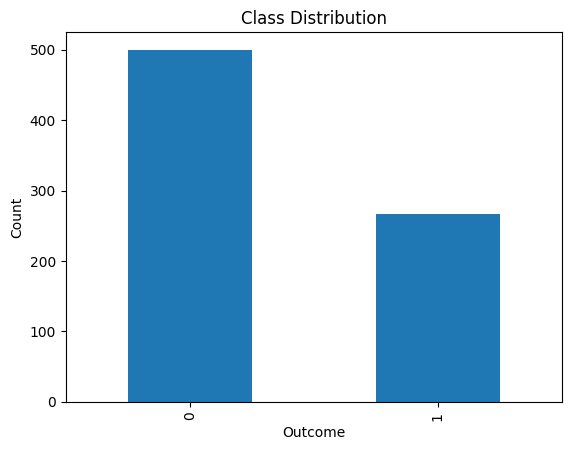

In [25]:
print(df["Outcome"].value_counts())

df["Outcome"].value_counts().plot(kind="bar")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

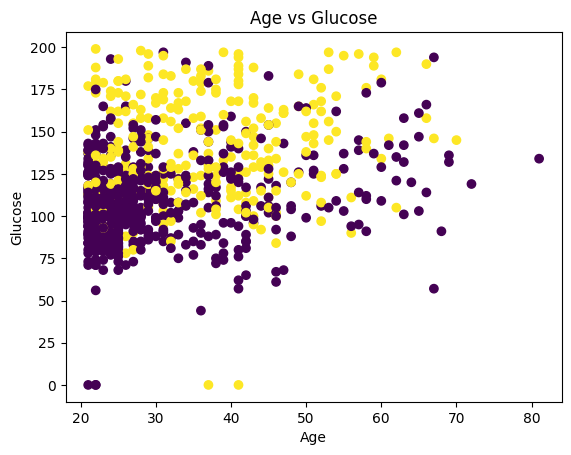

In [26]:
plt.scatter(df["Age"], df["Glucose"], c=df["Outcome"])
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.title("Age vs Glucose")
plt.show()

In [27]:
print("A simple linear boundary is not sufficient because diabetes depends on multiple features and the classes overlap.")

A simple linear boundary is not sufficient because diabetes depends on multiple features and the classes overlap.


#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [28]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[cols] = df[cols].replace(0, np.nan)

for col in cols:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [29]:
X = df.iloc[:, :8]
y = df.iloc[:, 8]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(613, 8)
(154, 8)


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [30]:
def get_bootstrap_sample(X, y):
    index = np.random.choice(len(X), len(X), replace=True)
    return X.iloc[index], y.iloc[index]

In [31]:
X_boot, y_boot = get_bootstrap_sample(X_train, y_train)

print("Original:", len(X_train))
print("Bootstrap:", len(X_boot))

Original: 613
Bootstrap: 613


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [12]:
ensemble = []

for i in range(50):
    X_boot, y_boot = get_bootstrap_sample(X_train, y_train)

    tree = DecisionTreeClassifier(max_depth=None, random_state=i)
    tree.fit(X_boot, y_boot)

    ensemble.append(tree)

print("Number of trees:", len(ensemble))

Number of trees: 50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [13]:
def custom_bagging_predict(ensemble, X_test):
    predictions = []

    for tree in ensemble:
        predictions.append(tree.predict(X_test))

    predictions = np.array(predictions)

    final = []

    for i in range(len(X_test)):
        final.append(np.bincount(predictions[:, i]).argmax())

    return np.array(final)

In [14]:
y_pred_bagging = custom_bagging_predict(ensemble, X_test)

print(y_pred_bagging)

[1 0 0 1 0 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 0 1 1 0 1 0 1 0 1 0 0 0 0 0 0 1 0
 0 1 1 1 0 0 0 0 0 0 0 1 0 1 1 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 1 0 1 0 0
 1 1 1 1 0 0 0 1 0 1 1 0 1 1 1 1 1 0 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 1 0 0
 0 0 0 0 0 0]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

In [15]:
tree = DecisionTreeClassifier(max_depth=None, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [16]:
print("Single Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1 Score:", f1_score(y_test, y_pred_tree))

print("\nCustom Bagging")
print("Accuracy:", accuracy_score(y_test, y_pred_bagging))
print("Precision:", precision_score(y_test, y_pred_bagging))
print("Recall:", recall_score(y_test, y_pred_bagging))
print("F1 Score:", f1_score(y_test, y_pred_bagging))

Single Decision Tree
Accuracy: 0.7207792207792207
Precision: 0.6078431372549019
Recall: 0.5740740740740741
F1 Score: 0.5904761904761905

Custom Bagging
Accuracy: 0.7402597402597403
Precision: 0.6346153846153846
Recall: 0.6111111111111112
F1 Score: 0.6226415094339622


In [17]:
print("Single Decision Tree")
print(confusion_matrix(y_test, y_pred_tree))

print("\nCustom Bagging")
print(confusion_matrix(y_test, y_pred_bagging))

Single Decision Tree
[[80 20]
 [23 31]]

Custom Bagging
[[81 19]
 [21 33]]


#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

In [18]:
tree_prob = tree.predict_proba(X_test)[:, 1]

bagging_prob = np.mean(
    [model.predict_proba(X_test)[:, 1] for model in ensemble],
    axis=0
)

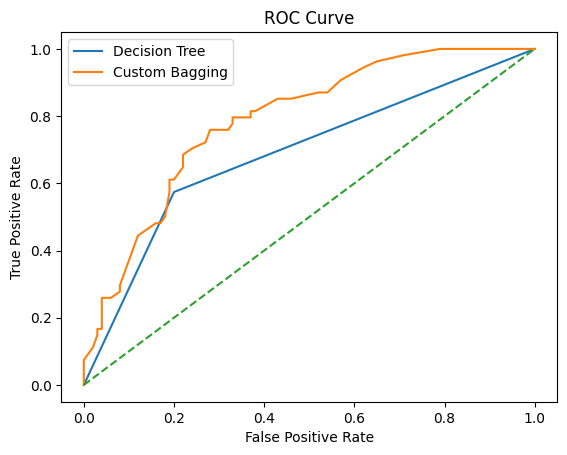

Decision Tree AUC: 0.6870370370370371
Bagging AUC: 0.7887037037037037


In [19]:
fpr1, tpr1, _ = roc_curve(y_test, tree_prob)
fpr2, tpr2, _ = roc_curve(y_test, bagging_prob)

auc1 = roc_auc_score(y_test, tree_prob)
auc2 = roc_auc_score(y_test, bagging_prob)

plt.plot(fpr1, tpr1, label="Decision Tree")
plt.plot(fpr2, tpr2, label="Custom Bagging")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("Decision Tree AUC:", auc1)
print("Bagging AUC:", auc2)

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [20]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None),
    n_estimators=50,
    random_state=42
)

bagging.fit(X_train, y_train)

y_pred_sklearn = bagging.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_sklearn))
print("Precision:", precision_score(y_test, y_pred_sklearn))
print("Recall:", recall_score(y_test, y_pred_sklearn))
print("F1 Score:", f1_score(y_test, y_pred_sklearn))

Accuracy: 0.7467532467532467
Precision: 0.6530612244897959
Recall: 0.5925925925925926
F1 Score: 0.6213592233009708


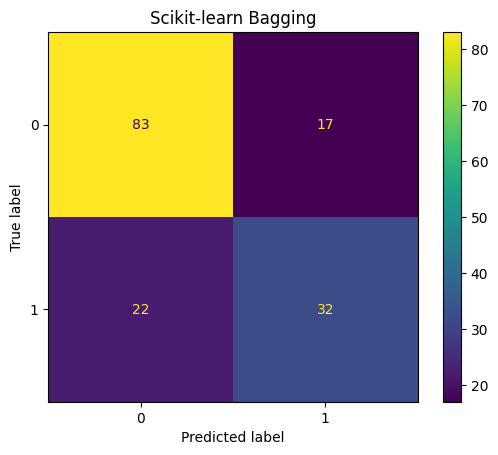

In [21]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_sklearn)
plt.title("Scikit-learn Bagging")
plt.show()

In [22]:
print("Single Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Custom Bagging Accuracy:", accuracy_score(y_test, y_pred_bagging))
print("Sklearn Bagging Accuracy:", accuracy_score(y_test, y_pred_sklearn))

Single Tree Accuracy: 0.7207792207792207
Custom Bagging Accuracy: 0.7402597402597403
Sklearn Bagging Accuracy: 0.7467532467532467


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?